# Data Challenge : Lynred data

---

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import json
import cv2
import glob, os
import matplotlib.pyplot as plt
from skimage import io
from scipy.ndimage import median_filter
from scipy.ndimage import convolve1d
from functions import get_defect_coordinates, load_json

---

## Loading the data

In [3]:
def load_images(folder='train',type='VGA',sequence='sequence_1', dyn='low dyn with columns 1', force_gray=False):
    """
    function that load a folder of images

    args : 
    folder : folder type
    type : type of the frame (HD, VGA, SXGA)
    sequence : sequence_1, sequence_2, sequence_3
    dyn : low dyn with columns 1, low dyn with columns 2, low dyn with columns 3
    force_gray : bool to load in gray (one array)

    return :
    list of the images of the folder
    """
    images = []
    if force_gray == True:
        for image in glob.glob(folder+'/'+type+'/'+sequence+'/'+dyn+'/*'):
            img = io.imread(image, as_gray=True)
            images.append(img)
    else:
        for image in glob.glob(folder+'/'+type+'/'+sequence+'/'+dyn+'/*'):
            img = io.imread(image)
            images.append(img)
    return images

In [4]:
def load_dataset(folder='train'):
    """
    function that load all the data set paths

    return : 
    dict : with every concept containing image paths
    list : with every image path
    """
    types = ['HD', 'SXGA', 'VGA']
    sequences = ['sequence_1', 'sequence_2', 'sequence_3']
    dynamics = [
        'high_dyn',
        'low dyn',
        'low dyn with columns 1',
        'low dyn with columns 2',
        'low dyn with columns 3'
    ]

    dataset_dict = {}
    all_images_list = []

    for t in types:
        dataset_dict[t] = {}
        for seq in sequences:
            dataset_dict[t][seq] = {}
            for dyn in dynamics:

                # Récupère que les fichiers png du dossier
                path_pattern = f"{folder}/{t}/{seq}/{dyn}/*.png"
                
                paths_in_folder = glob.glob(path_pattern)
                
                dataset_dict[t][seq][dyn] = paths_in_folder
                all_images_list.extend(paths_in_folder)

    return dataset_dict, all_images_list

In [5]:
def convert_to_8_img(img_16bit):
    """""
    Convert 16 bits img into 8 bits using percentiles to not be biased by outliers  
    arg : img 
    return : converted img in 8 bits
    """""
    # 1. Utiliser des percentiles pour ignorer les pixels aberrants (très chauds ou très froids)
    # Cela permet de mieux voir les détails de la scène sans être ébloui par les extrêmes
    p2, p98 = np.percentile(img_16bit, (2, 98))
    img_clipped = np.clip(img_16bit, p2, p98)
    
    # 2. Normaliser entre 0 et 255
    img_8bit = ((img_clipped - p2) / (p98 - p2) * 255).astype(np.uint8)
    return img_8bit

In [6]:
minus_datetrain = load_images()

## Explore the Dataset

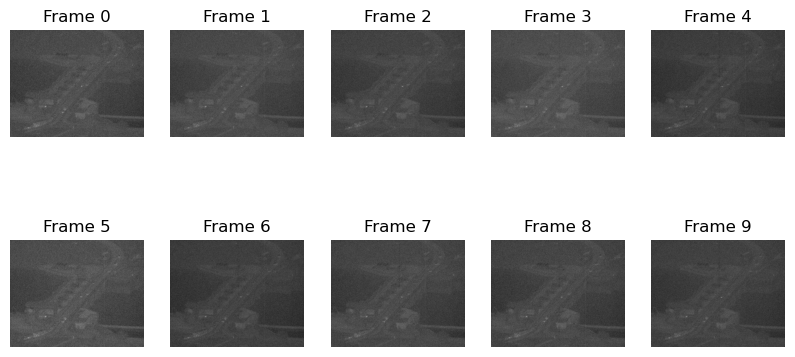

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(0,2,1):
    for j in range(0,5,1):
        index_image = i * 5 + j 
        axes[i, j].imshow(minus_datetrain[index_image], cmap='gray')
        axes[i, j].set_title(f'Frame {index_image}')
        axes[i, j].axis('off')

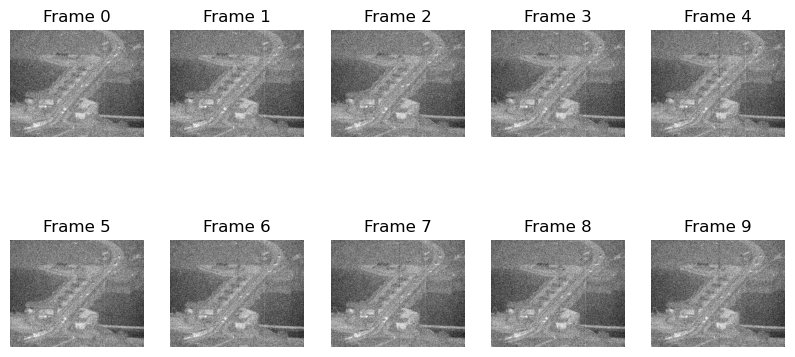

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i in range(0,2,1):
    for j in range(0,5,1):
        index_image = i * 5 + j 
        axes[i, j].imshow(convert_to_8_img(minus_datetrain[index_image]), cmap='gray')
        axes[i, j].set_title(f'Frame {index_image}')
        axes[i, j].axis('off')

---
## First find defects columns by using the variance

Seuil fixé à : 33316.38
Nombre de colonnes dépassant le seuil : 2
Index de ces colonnes : [395 450]
Seuil fixé à : 1309.40
Nombre de colonnes dépassant le seuil : 21
Index de ces colonnes : [  3  20  86  87  88  89  97 100 112 116 118 122 135 136 169 170 341 342
 485 503 622]


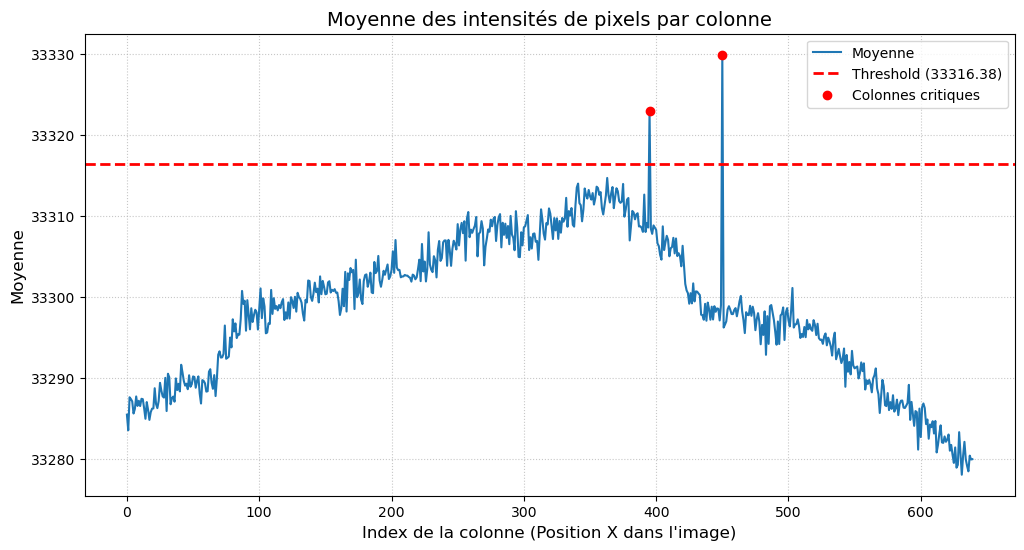

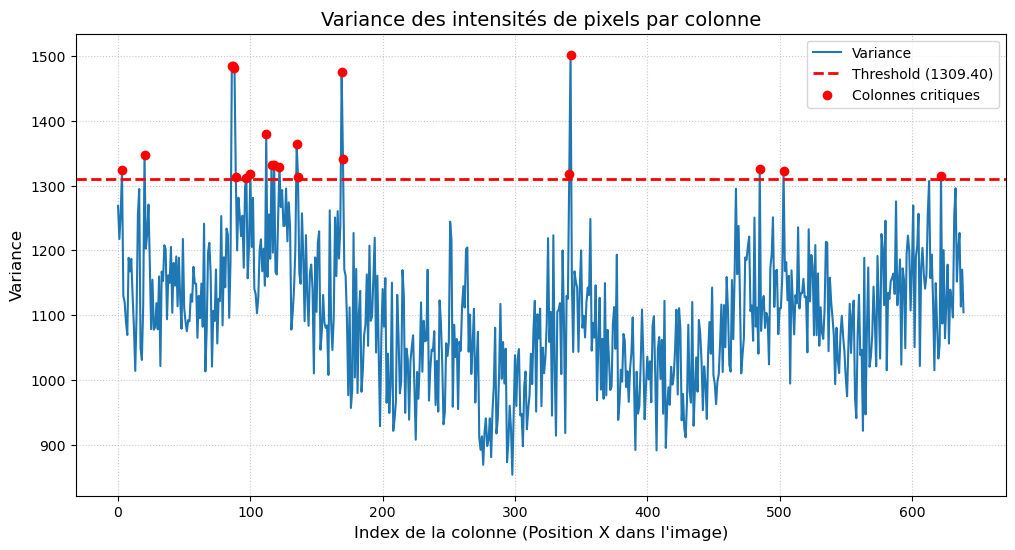

In [9]:
def metrique_img(image, mean_not_var = True):
    """
    Fonction pour discriminer avec la variance avec un threshold global
    """
    hauteur, longueur = image.shape
    if mean_not_var:
        var = np.mean(image, axis=0)
        label = 'Moyenne'
    else:
        var = np.var(image, axis=0)
        label = 'Variance'
    threshold = np.mean(var) + 2*np.std(var)
    defect_columns = np.where(var > threshold)[0]
    print(f"Seuil fixé à : {threshold:.2f}")
    print(f"Nombre de colonnes dépassant le seuil : {len(defect_columns)}")
    print(f"Index de ces colonnes : {defect_columns}")

    plt.figure(figsize=(12, 6))
    
    # Tracer la courbe de toutes les variances/moyennes
    plt.plot(var, label=label, color='#1f77b4', linewidth=1.5)
    
    # Tracer la ligne du threshold (seuil)
    plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.2f})')
    
    # Mettre un point rouge sur le graphe pour chaque "pire" colonne
    plt.scatter(defect_columns, var[defect_columns], color='red', zorder=5, label='Colonnes critiques')

    # Personnalisation du graphe
    plt.title(f'{label} des intensités de pixels par colonne', fontsize=14)
    plt.xlabel("Index de la colonne (Position X dans l'image)", fontsize=12)
    plt.ylabel(f'{label}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

metrique_img(minus_datetrain[0])
metrique_img(minus_datetrain[0], mean_not_var=False)

> Just to know we have a noisy columns in Img[0] at x = 395 AND a blinking one at x = 450.

On observe que les bonnes détections faites sont réussies par la moyenne, mais notre threshold est global donc ne s'adapte pas à l'évolution dans l'image.

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.85
Nombre de colonnes dépassant le seuil local : 2
Index de ces colonnes : [395 450]


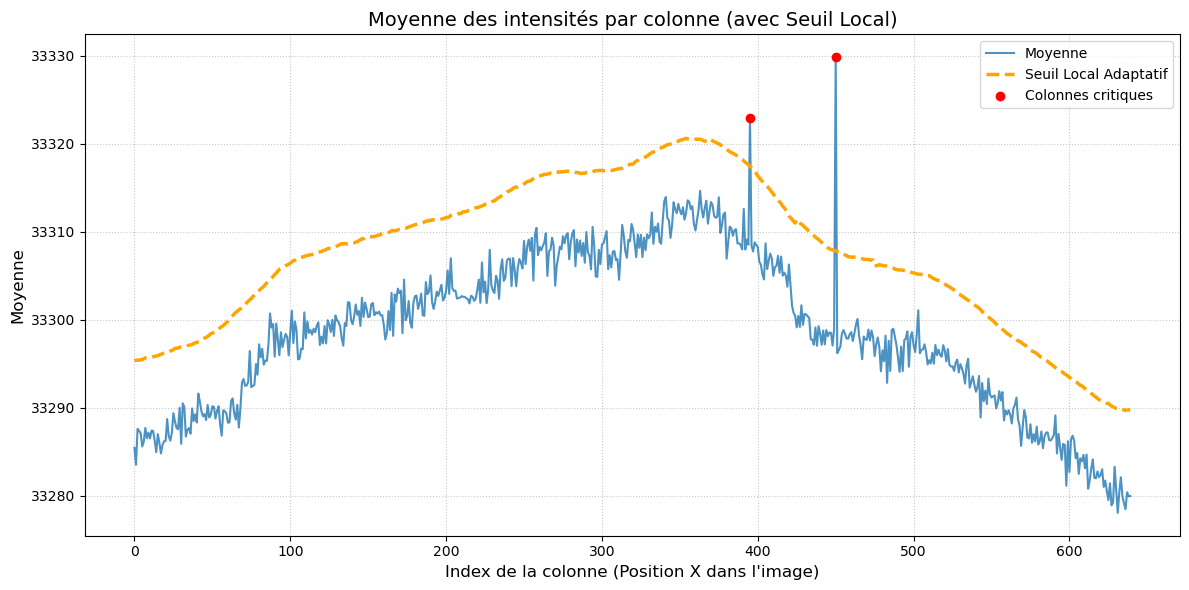

--------------------------------------------------
Analyse basée sur : Variance
Marge de tolérance (+ 2*std) : 104.51
Nombre de colonnes dépassant le seuil local : 56
Index de ces colonnes : [  3  16  20  23  86  87  88  89 112 116 118 122 135 136 160 164 166 168
 169 170 178 190 194 215 234 251 252 261 263 264 289 325 329 341 342 350
 357 377 413 467 469 481 485 495 503 522 535 536 577 580 588 601 605 613
 622 633]


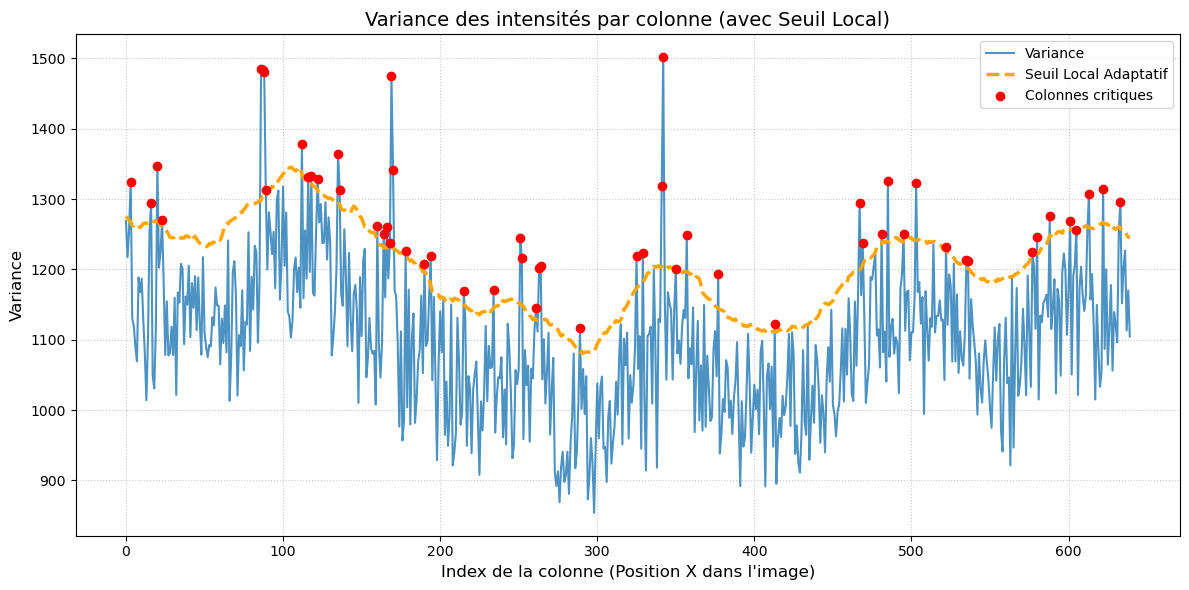

In [10]:
def metrique_img_local(image, mean_not_var=True, taille_fenetre=50):
    """
    Fonction pour discriminer les colonnes anormales avec un threshold LOCAL adaptatif.
    """
    if mean_not_var:
        metrique = np.mean(image, axis=0)
        label = 'Moyenne'
    else:
        metrique = np.var(image, axis=0)
        label = 'Variance'
        
    # 2. Calcul du Seuil Local
    # a) Calcul de la tendance locale (moyenne glissante)
    filtre = np.ones(taille_fenetre) / taille_fenetre
    tendance_locale = convolve1d(metrique, filtre, mode='reflect')
    
    # b) Marge de tolérance
    marge_tolerance = np.std(metrique)
    
    # Le seuil n'est plus un simple nombre, c'est un tableau de la même taille que l'image !
    threshold_local = tendance_locale + marge_tolerance
    
    # 3. Détection des anomalies
    # On compare chaque colonne avec SON seuil local
    defect_columns = np.where(metrique > threshold_local)[0]
    
    print(f"Analyse basée sur : {label}")
    print(f"Marge de tolérance (+ 2*std) : {marge_tolerance:.2f}")
    print(f"Nombre de colonnes dépassant le seuil local : {len(defect_columns)}")
    print(f"Index de ces colonnes : {defect_columns}")

    # 4. Affichage du graphe
    plt.figure(figsize=(12, 6))
    
    # Tracer la courbe de toutes les variances/moyennes
    # Correction : label=label (sans les guillemets)
    plt.plot(metrique, label=label, color='#1f77b4', linewidth=1.5, alpha=0.8)
    
    # Tracer la courbe du threshold local
    # On utilise plt.plot au lieu de axhline car le seuil n'est plus une ligne droite horizontale
    plt.plot(threshold_local, color='orange', linestyle='--', linewidth=2.5, label='Seuil Local Adaptatif')
    
    # Mettre un point rouge sur le graphe pour chaque "pire" colonne
    plt.scatter(defect_columns, metrique[defect_columns], color='red', zorder=5, label='Colonnes critiques')

    # Personnalisation du graphe
    plt.title(f'{label} des intensités par colonne (avec Seuil Local)', fontsize=14)
    plt.xlabel('Index de la colonne (Position X dans l\'image)', fontsize=12)
    plt.ylabel(f'{label}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

metrique_img_local(minus_datetrain[0], mean_not_var=True)
print(50*'-')
metrique_img_local(minus_datetrain[0], mean_not_var=False)

On observe bien que la méthode de la variance est pas du tout pertinente.

## Testons sur d'autres images

Seuil fixé à : 34115.57
Nombre de colonnes dépassant le seuil : 1
Index de ces colonnes : [450]
--------------------------------------------------
Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.84
Nombre de colonnes dépassant le seuil local : 1
Index de ces colonnes : [450]


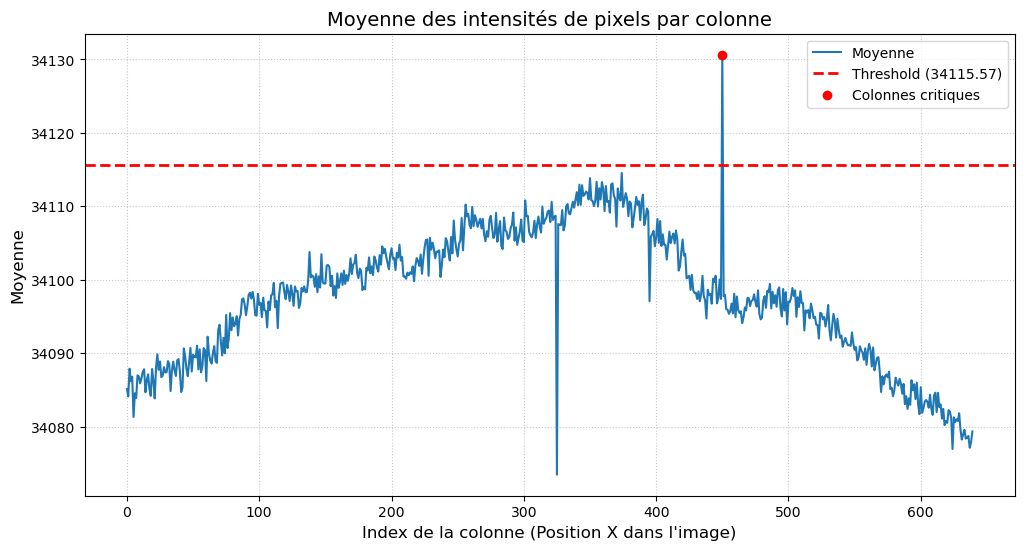

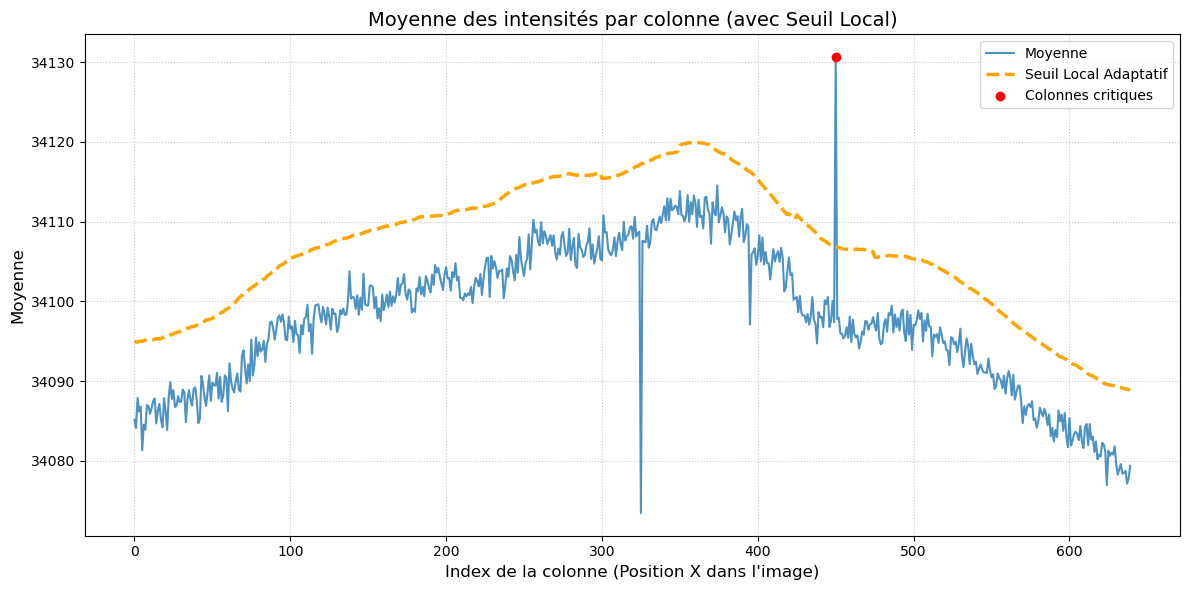

In [11]:
metrique_img(minus_datetrain[3], mean_not_var=True)
print(50*'-')
metrique_img_local(minus_datetrain[3], mean_not_var=True)

Comme on peut le voir on doit appliquer dans les deux sens (logique).

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.84
Nombre de colonnes dépassant le seuil local : 3
Index de ces colonnes : [325 395 450]


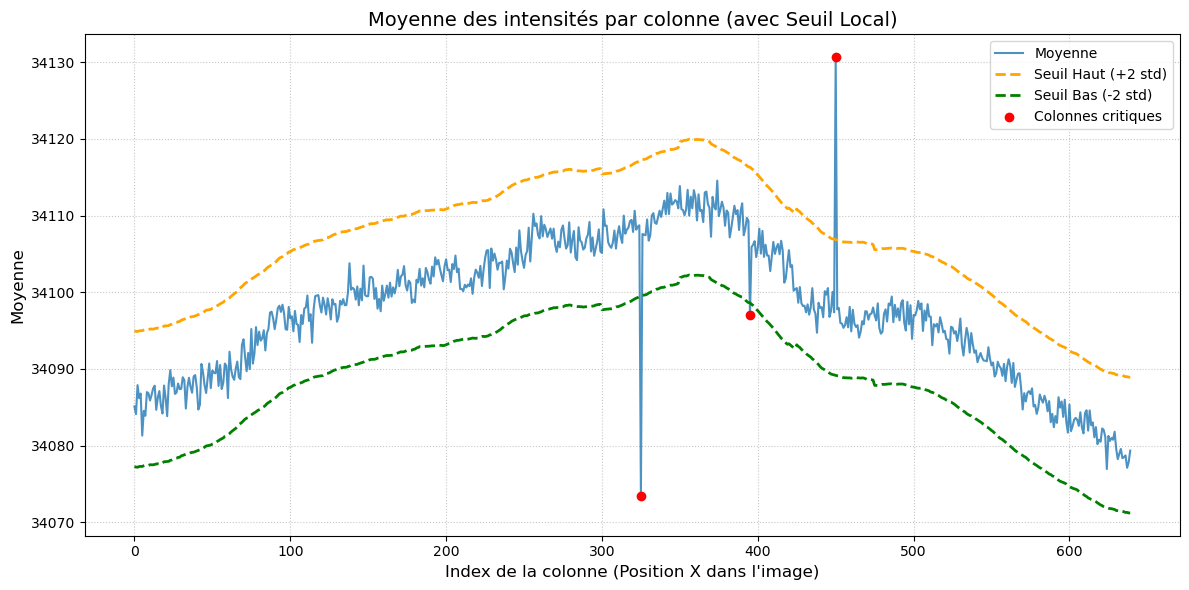

In [12]:
def mean_threshold_local(image, taille_fenetre=50):

    metrique = np.mean(image, axis=0)
    label = 'Moyenne'

    filtre = np.ones(taille_fenetre) / taille_fenetre
    tendance_locale = convolve1d(metrique, filtre, mode='reflect')
    
    #Marge de tolérance
    marge_tolerance = np.std(metrique)
    
    # Le seuil n'est plus un simple nombre, c'est un tableau de la même taille que l'image !
    threshold_haut = tendance_locale + marge_tolerance
    threshold_bas = tendance_locale - marge_tolerance
    
    # Détection bilatérale avec l'écart absolu (np.abs)
    defect_columns = np.where(np.abs(metrique - tendance_locale) > marge_tolerance)[0]

    # Printing results    
    print(f"Analyse basée sur : {label}")
    print(f"Marge de tolérance (+ 2*std) : {marge_tolerance:.2f}")
    print(f"Nombre de colonnes dépassant le seuil local : {len(defect_columns)}")
    print(f"Index de ces colonnes : {defect_columns}")

    # Affichage du graphe
    plt.figure(figsize=(12, 6))
    
    # Tracer la courbe de toutes les variances/moyennes
    plt.plot(metrique, label=label, color='#1f77b4', linewidth=1.5, alpha=0.8)
    
    # Tracer la courbe du threshold local
    plt.plot(threshold_haut, color='orange', linestyle='--', linewidth=2, label='Seuil Haut (+2 std)')
    plt.plot(threshold_bas, color='green', linestyle='--', linewidth=2, label='Seuil Bas (-2 std)')
    
    # Mettre un point rouge sur le graphe pour chaque "pire" colonne
    plt.scatter(defect_columns, metrique[defect_columns], color='red', zorder=5, label='Colonnes critiques')

    # Personnalisation du graphe
    plt.title(f'{label} des intensités par colonne (avec Seuil Local)', fontsize=14)
    plt.xlabel('Index de la colonne (Position X dans l\'image)', fontsize=12)
    plt.ylabel(f'{label}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

mean_threshold_local(minus_datetrain[3])

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.85
Nombre de colonnes dépassant le seuil local : 2
Index de ces colonnes : [395 450]


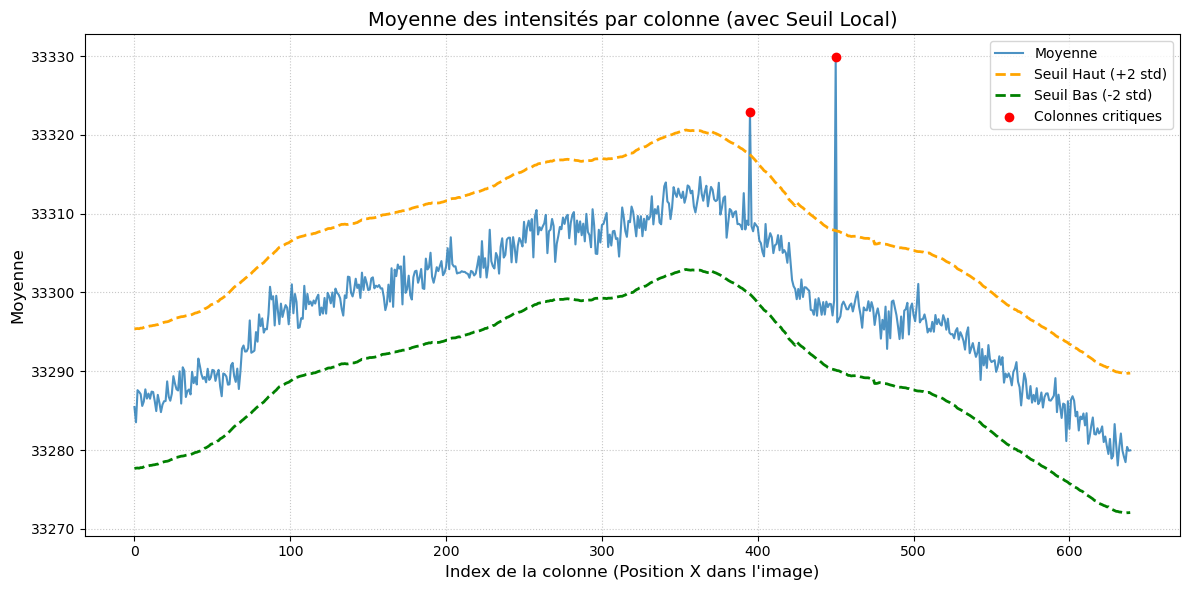

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.81
Nombre de colonnes dépassant le seuil local : 2
Index de ces colonnes : [395 450]


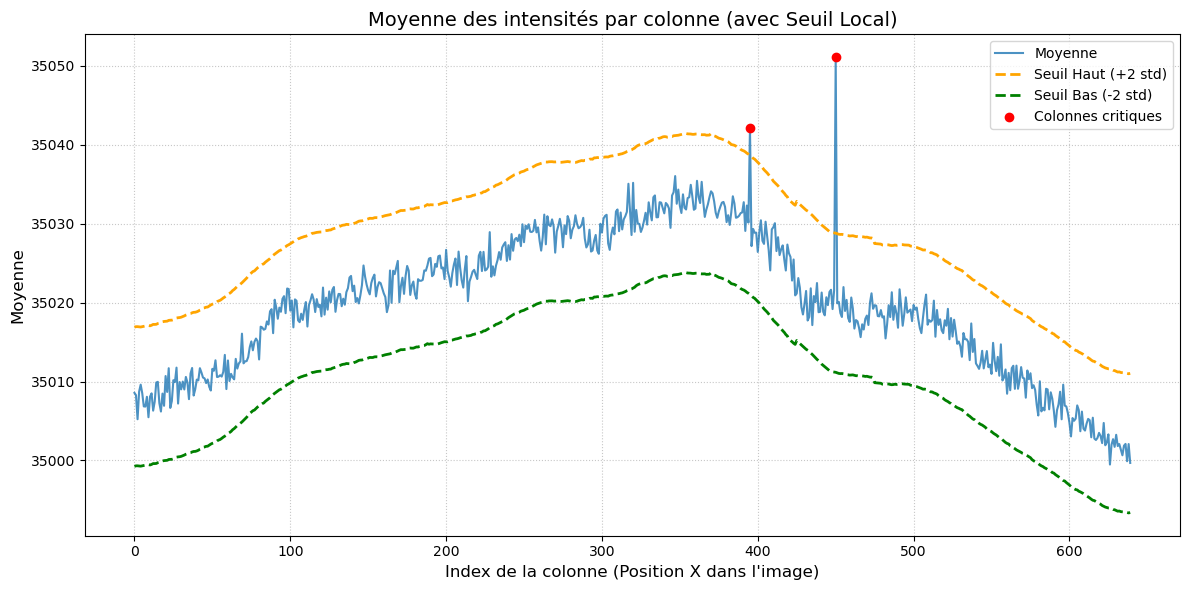

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.86
Nombre de colonnes dépassant le seuil local : 2
Index de ces colonnes : [395 450]


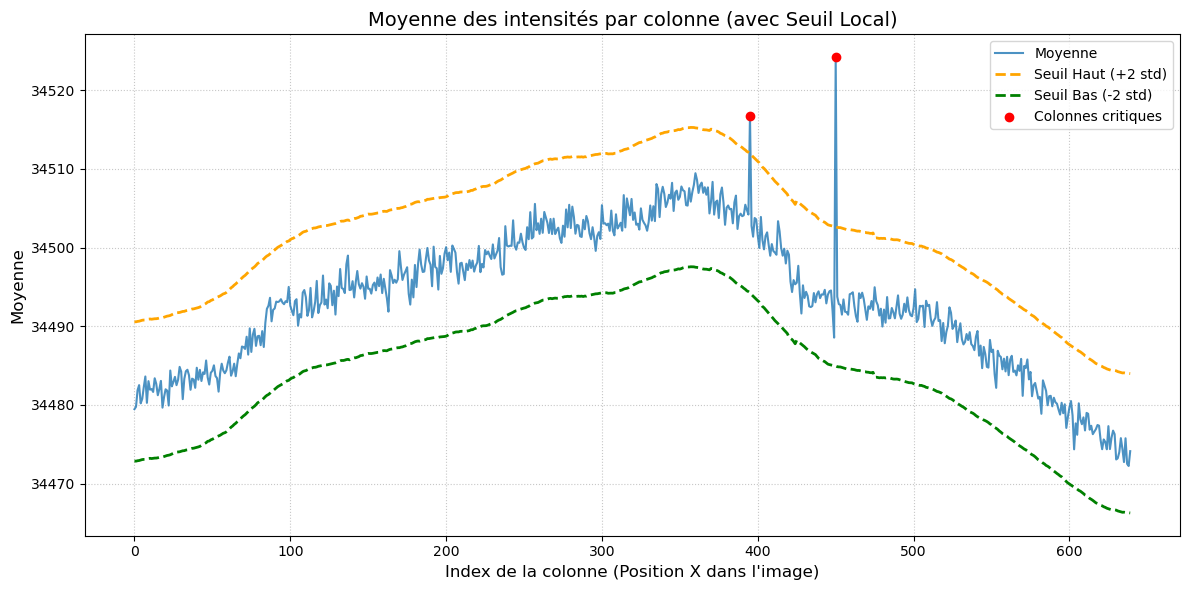

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.84
Nombre de colonnes dépassant le seuil local : 3
Index de ces colonnes : [325 395 450]


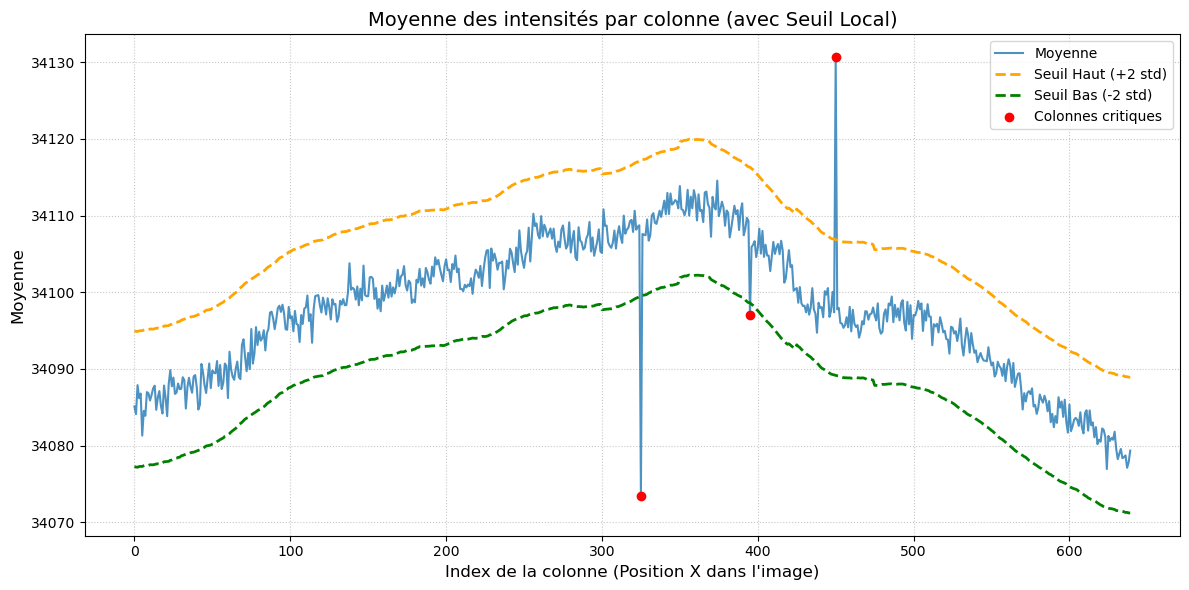

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 9.07
Nombre de colonnes dépassant le seuil local : 3
Index de ces colonnes : [325 395 450]


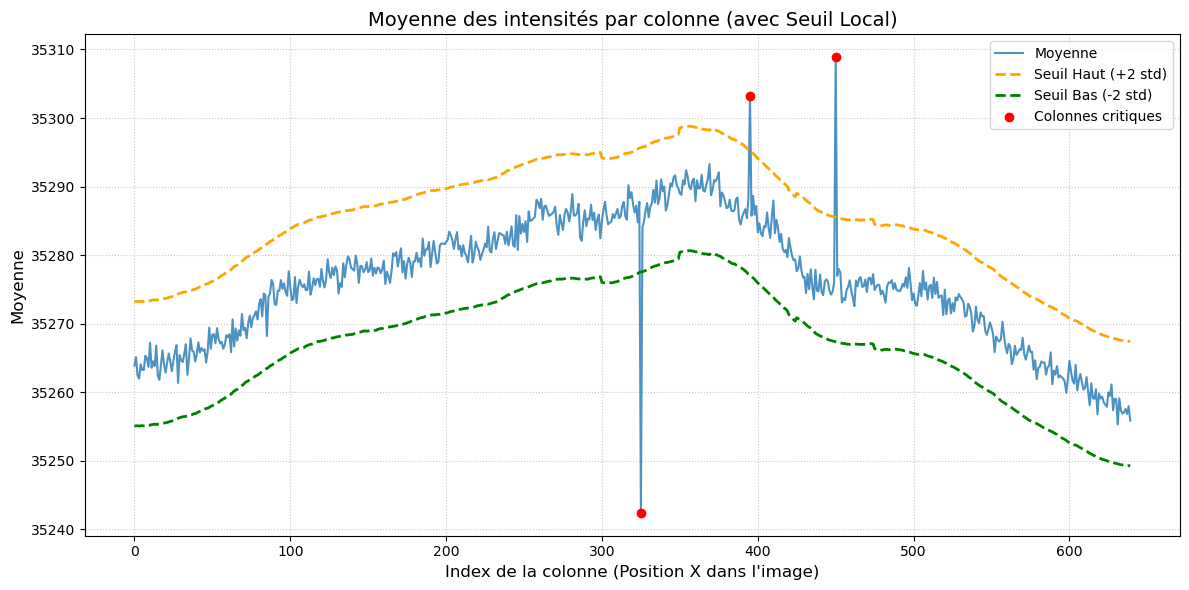

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.80
Nombre de colonnes dépassant le seuil local : 3
Index de ces colonnes : [325 395 450]


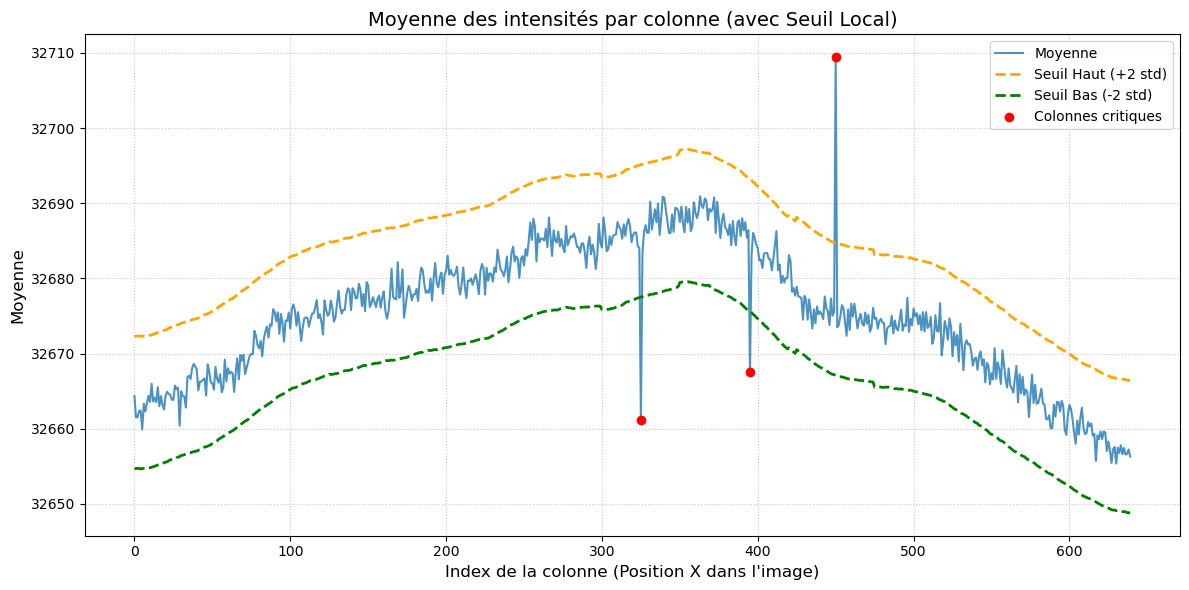

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.78
Nombre de colonnes dépassant le seuil local : 2
Index de ces colonnes : [325 450]


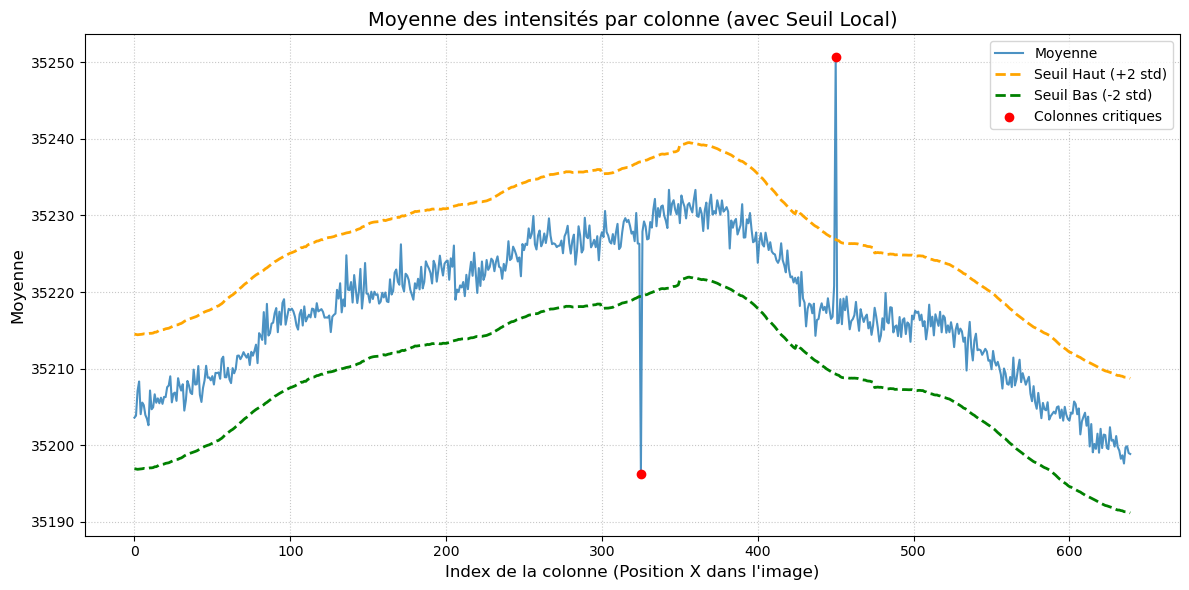

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.91
Nombre de colonnes dépassant le seuil local : 2
Index de ces colonnes : [325 450]


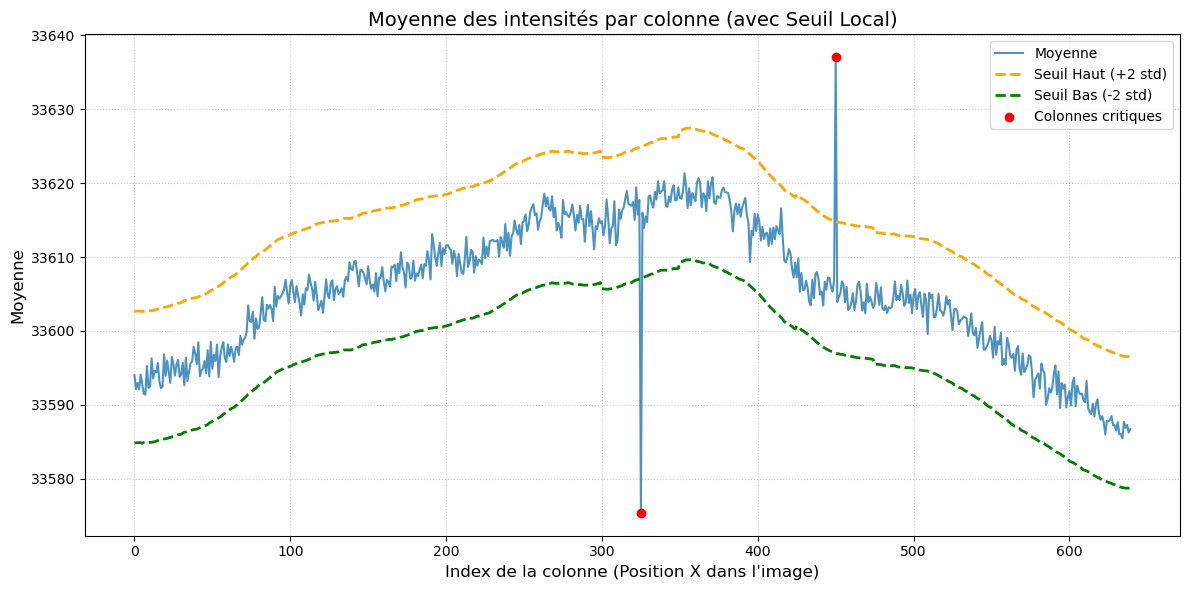

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.84
Nombre de colonnes dépassant le seuil local : 2
Index de ces colonnes : [325 450]


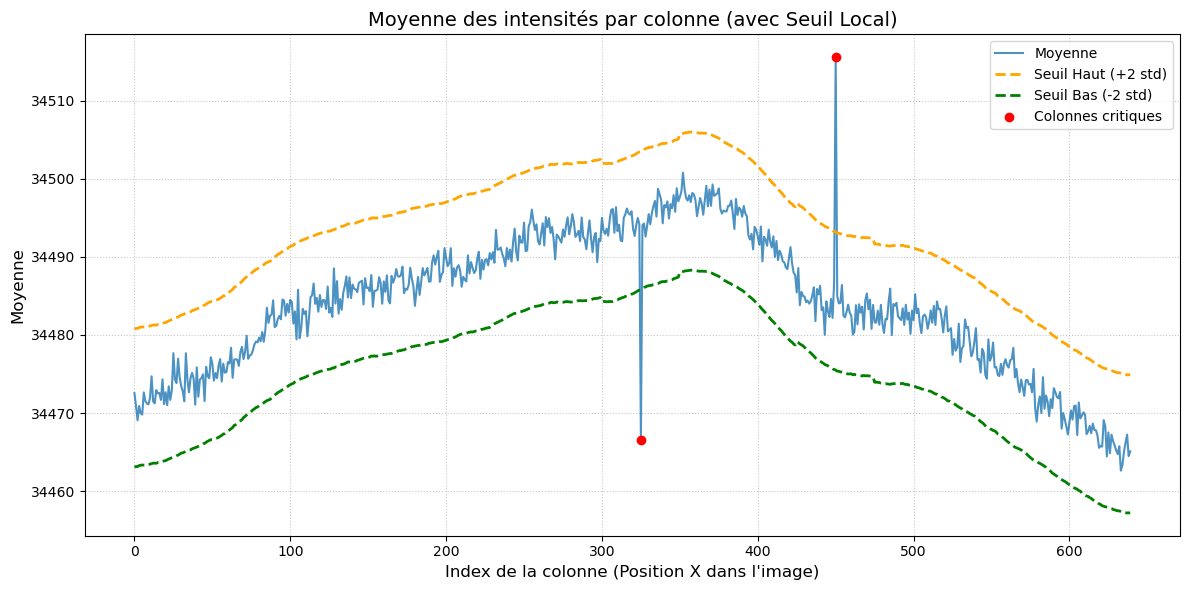

Analyse basée sur : Moyenne
Marge de tolérance (+ 2*std) : 8.88
Nombre de colonnes dépassant le seuil local : 1
Index de ces colonnes : [325]


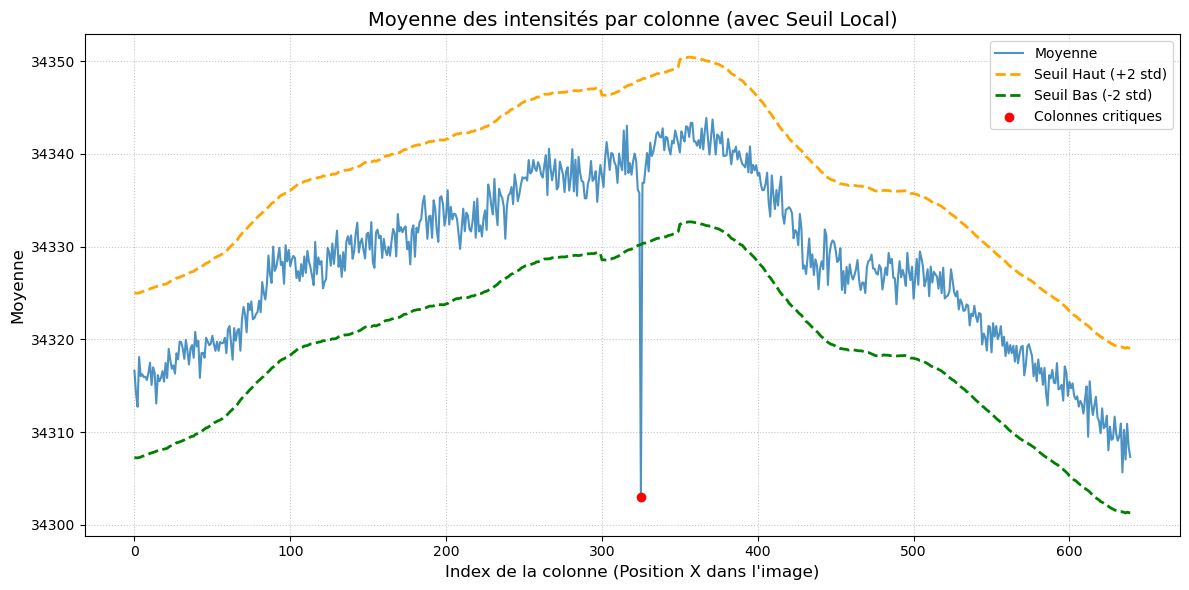

In [13]:
for img in minus_datetrain:
    mean_threshold_local(img)

Ici ça marche vrmt super mais c'est un peu ce qu'on attends d'erreurs grossières comme ça, j'en profite pour regarder avec 

---

# Fragmented columns

## Using Bands

---

## Try to detect blinky noisy columns (not fragmented)

> L'idée est de voir les les pixels comme ayant 3 valeurs (x,y,t), t étant le temps. 

On voudrait supprimer le reste de l'image soit pas soustraction, soit pas dérivation pour garder que les différences un peu particulières des images au cours du temps.

---

# Création d'une fonction d'évaluation de nos méthodes de détections

In [14]:
print(get_defect_coordinates(load_json("VGA_sequence_1_config_1.json"), 0))

{395: {'start': [0], 'stop': [640], 'type': 'noisy'}, 450: {'start': [0], 'stop': [640], 'type': 'blinking'}}
